<a href="https://colab.research.google.com/github/DavidAgudeloM/ProblemaBancario/blob/main/EA3_SOLUCION_PROBEMA_BANCARIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EVIDENCIA DE APRENDIZAJE # 3**


---
**SOLUCION DE UN PROBLEMA BANCARIO **::

El Banco de Colombia está interesado en medir el desempeño de sus cajeros durante las operaciones de pagos y retiros, pues no cuenta con cajeros electrónicos y considera conveniente tener cajas disponibles para que los ciudadanos realicen sus operaciones sin demora. El banco desea saber si debe asignar una caja exclusiva para retiros y dos para pagos, o viceversa, esto con el propósito de adoptar las adecuaciones necesarias en miras de prestar el mejor servicio posible a sus usuarios.

Para resolver este caso, presta atención a la siguiente información:

* El banco dispone de tres cajas para ambas finalidades (pagos y retiros), las
cuales prestan su servicio de acuerdo con el tipo de usuario.  

* En la Tabla 1 se definen los tipos de usuario, detallando los tiempos de llegada y servicio estimados para cada uno con base en la acción que deseen realizar. Ten en cuenta que el 70 % de los usuarios hace retiros, mientras que los demás realizan consignaciones o pagos.

* Por otro lado, los cajeros se deben simular como modelos M/M/1, pues son independientes. Además, se asume que la velocidad de atención es igual para todos los cajeros (inmediata) y la velocidad de desplazamiento es despreciable.  

* El banco opera 8 horas al día. Se puede asumir que los días son iguales y establecer las sugerencias necesarias a partir de la modelación de un solo día y sus réplicas.

**Ejecuta al menos 10 corridas del modelo y calcula las estadísticas necesarias para resolver los siguientes puntos:**

* Calcula las estadísticas necesarias para identificar el cajero con menor y mayor tiempo promedio de atención (no es necesario segregar los usuarios).

* Establece el promedio de usuarios de cada tipo en la totalidad de cajeros.

* Determina el total de usuarios de cada tipo en cada una de las réplicas y detalla el modelo con menor cantidad de usuarios por tipo.

* Define si es necesario crear un nuevo cajero utilizando los tiempos promedio de espera en todos los criterios del modelo.

* Decide cuántos cajeros deben ofrecer atención exclusiva para pagos y cuántos para retiros.

🏦 SIMULACIÓN DE OPERACIONES BANCARIAS

Configuración base:
  - Cajeros: 3
  - Horas de operación: 8
  - Réplicas: 10

🔄 Ejecutando simulación base (3 cajas mixtas)...
Ejecutando réplica 1/10...
Ejecutando réplica 2/10...
Ejecutando réplica 3/10...
Ejecutando réplica 4/10...
Ejecutando réplica 5/10...
Ejecutando réplica 6/10...
Ejecutando réplica 7/10...
Ejecutando réplica 8/10...
Ejecutando réplica 9/10...
Ejecutando réplica 10/10...

ANÁLISIS DE RESULTADOS

📊 ESTADÍSTICAS GENERALES:
   Total de clientes atendidos: 2009
   Tiempo promedio de espera: 0.40 min
   Tiempo promedio de servicio: 3.21 min

🏦 TIEMPO PROMEDIO DE SERVICIO POR CAJERO:
   Cajero 0: 3.52 min
   Cajero 1: 3.03 min
   Cajero 2: 2.95 min

   ⚡ Cajero más rápido: Cajero 2 (2.95 min)
   🐢 Cajero más lento: Cajero 0 (3.52 min)

👥 DISTRIBUCIÓN DE USUARIOS POR TIPO:

   RETIROS:
      Rápido: 318 clientes (22.8%)
      Normal: 578 clientes (41.4%)
      Lento: 238 clientes (17.0%)
      Muy lento: 263 clientes (18.8%)

   

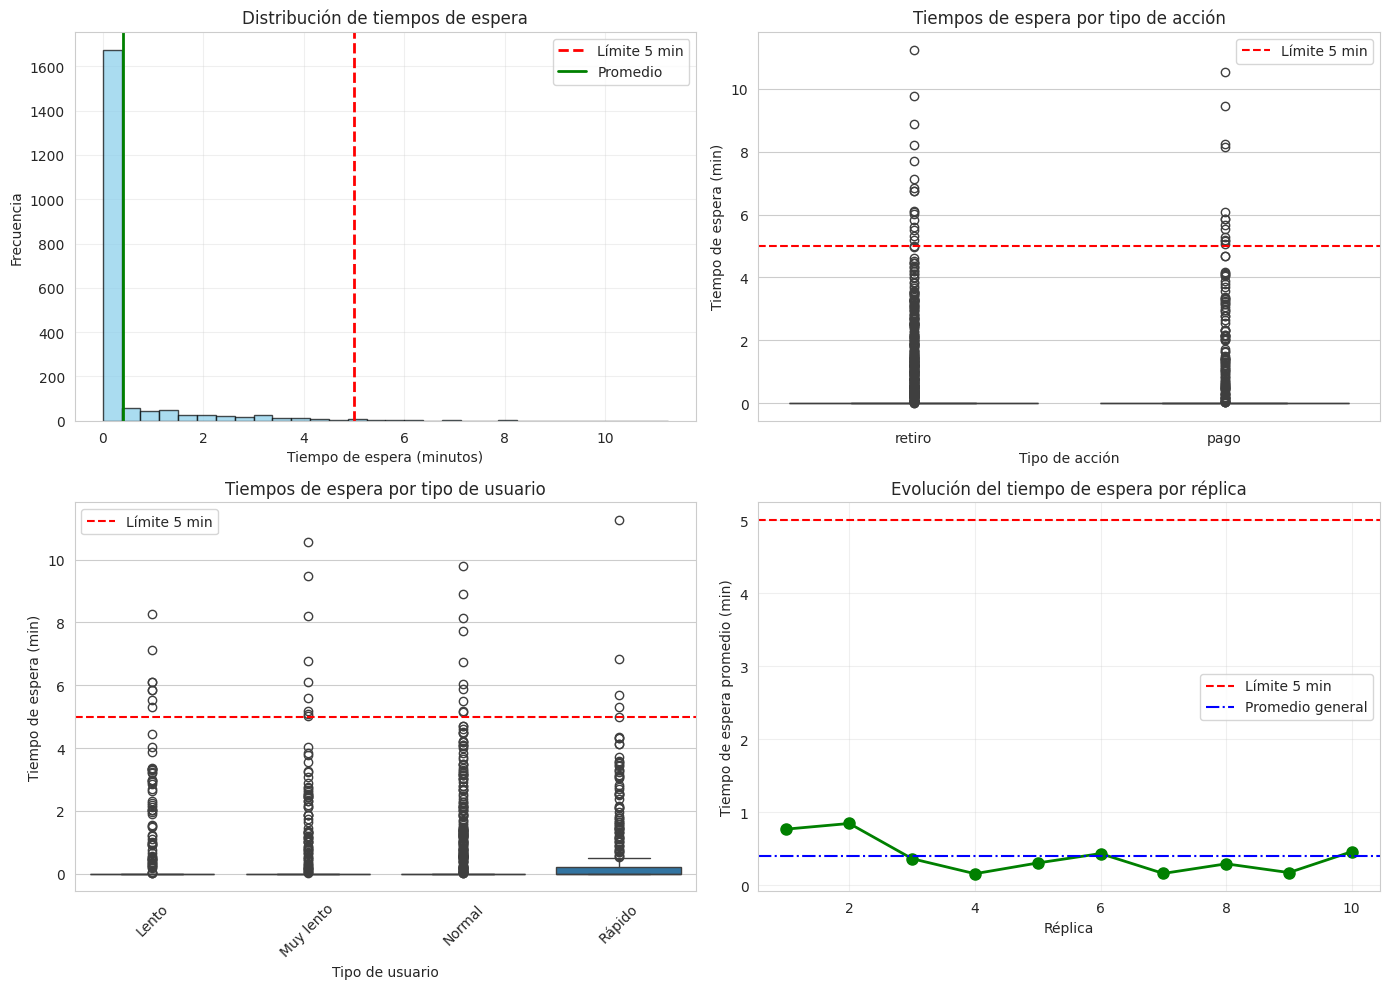

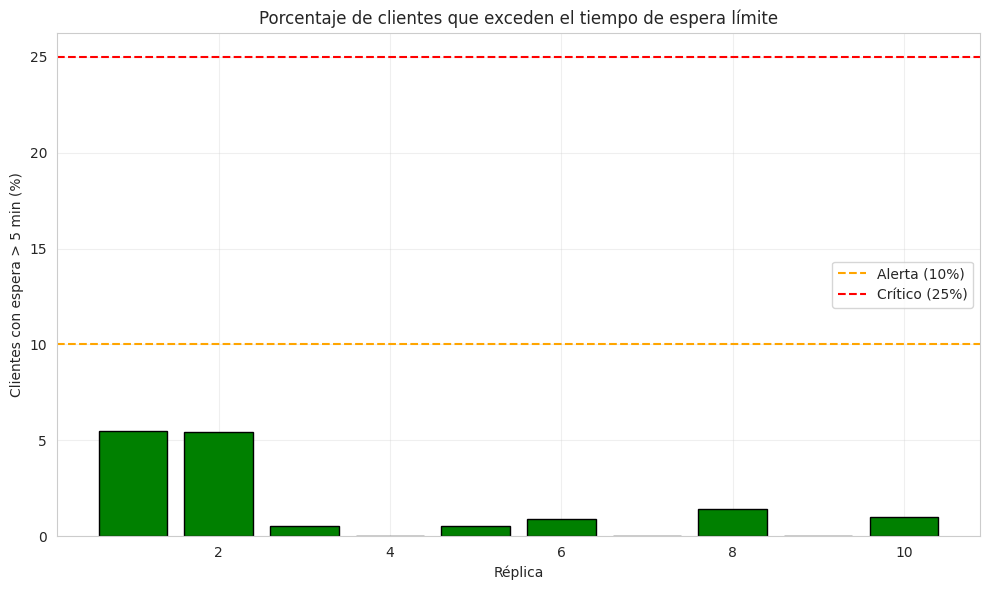


🎯 PUNTO 5: ANÁLISIS DE CONFIGURACIONES ESPECIALIZADAS

🎯 PUNTO 5: ANÁLISIS DE CONFIGURACIÓN ÓPTIMA

🔄 Ejecutando simulaciones para cada configuración...
--------------------------------------------------

📊 A: 3 Mixtas
   Tres cajas mixtas (línea base)
Ejecutando réplica 1/10...
Ejecutando réplica 2/10...
Ejecutando réplica 3/10...
Ejecutando réplica 4/10...
Ejecutando réplica 5/10...
Ejecutando réplica 6/10...
Ejecutando réplica 7/10...
Ejecutando réplica 8/10...
Ejecutando réplica 9/10...
Ejecutando réplica 10/10...

📊 B: 1 Retiro + 2 Pagos
   Una caja exclusiva para retiros, dos para pagos
   Réplica 1/10...
   Réplica 2/10...
   Réplica 3/10...
   Réplica 4/10...
   Réplica 5/10...
   Réplica 6/10...
   Réplica 7/10...
   Réplica 8/10...
   Réplica 9/10...
   Réplica 10/10...

📊 C: 2 Retiros + 1 Pago
   Dos cajas exclusivas para retiros, una para pagos
   Réplica 1/10...
   Réplica 2/10...
   Réplica 3/10...
   Réplica 4/10...
   Réplica 5/10...
   Réplica 6/10...
   Réplica 7/10.

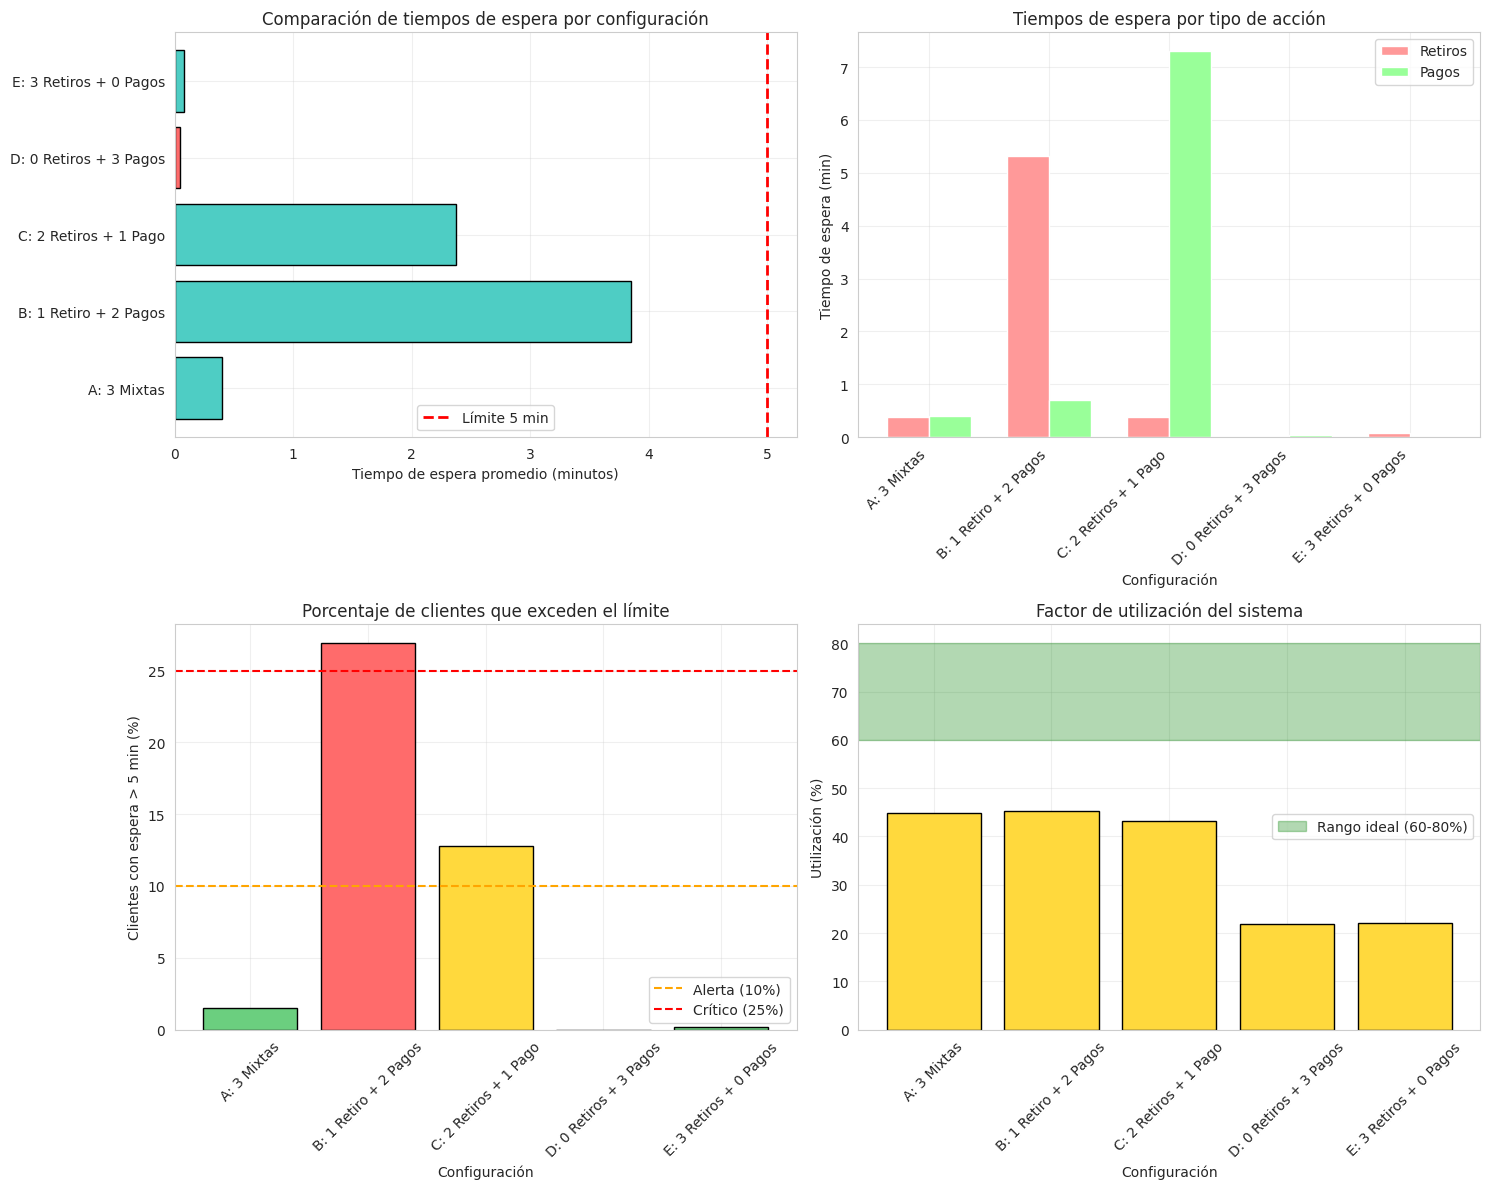

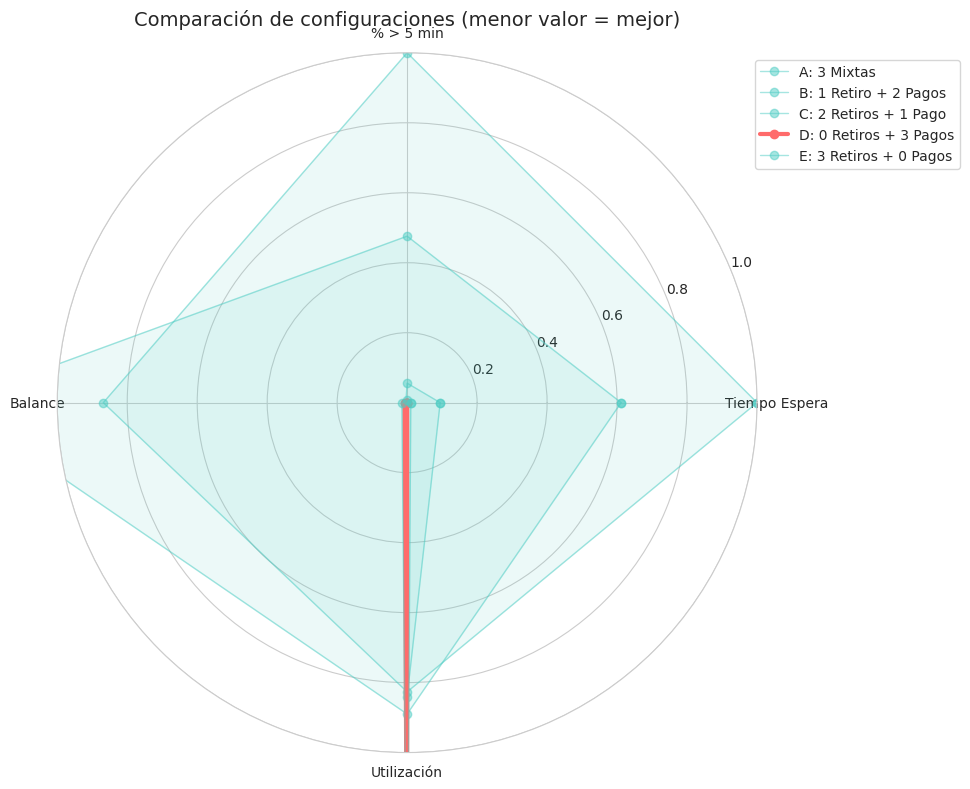


💾 Análisis de configuraciones guardado en 'analisis_configuraciones_optimas.xlsx'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


💾 Guardando resultados completos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ SIMULACIÓN COMPLETADA EXITOSAMENTE


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# ============================================
# CLASE PARA SIMULACIÓN CON CAJEROS EXCLUSIVOS
# ============================================

class BankSimulationEspecializada:
    """
    Simulación de banco con cajeros especializados por tipo de acción
    """
    def __init__(self, num_cajeros_retiro=0, num_cajeros_pago=0, horas_operacion=8):
        self.num_cajeros_retiro = num_cajeros_retiro
        self.num_cajeros_pago = num_cajeros_pago
        self.num_cajeros_total = num_cajeros_retiro + num_cajeros_pago
        self.tiempo_simulacion = horas_operacion * 60  # Convertir a minutos

        # Si no hay cajeros especializados, usar configuración mixta
        if self.num_cajeros_total == 0:
            self.num_cajeros_total = 3
            self.es_mixto = True
        else:
            self.es_mixto = False

        # Probabilidades de tipo de acción
        self.prob_retiro = 0.7
        self.prob_pago = 0.3

        # Probabilidades de tipo de usuario
        self.prob_usuario_retiro = [0.23, 0.40, 0.17, 0.20]
        self.prob_usuario_pago = [0.10, 0.20, 0.30, 0.40]

        # Tiempos de servicio
        self.servicio_retiro = [1, 2, 3, 4]
        self.servicio_pago = [3, 3, 5, 7]

        # Tiempos de llegada
        self.llegada_retiro = [1, 2, 3, 3]
        self.llegada_pago = [1, 2, 3, 4]

    def generar_tiempo_exponencial(self, media):
        return np.random.exponential(media)

    def generar_tipo_accion(self):
        return 'retiro' if np.random.random() < self.prob_retiro else 'pago'

    def generar_tipo_usuario(self, tipo_accion):
        if tipo_accion == 'retiro':
            return np.random.choice([0, 1, 2, 3], p=self.prob_usuario_retiro)
        else:
            return np.random.choice([0, 1, 2, 3], p=self.prob_usuario_pago)

    def simular_dia(self, semilla=None):
        """Simula un día con cajeros especializados"""
        if semilla is not None:
            np.random.seed(semilla)

        # Inicializar estadísticas
        clientes_atendidos = []

        # Estado de cajeros: [ocupado, tipo_asignado] para cada cajero
        # tipo_asignado: 'retiro', 'pago', o None si es mixto
        cajeros_estado = []

        if self.es_mixto:
            # Configuración mixta: todos atienden todo
            for i in range(self.num_cajeros_total):
                cajeros_estado.append({'ocupado': 0, 'tipo': None})
        else:
            # Configuración especializada
            # Primeros N cajeros para retiros, siguientes M para pagos
            for i in range(self.num_cajeros_retiro):
                cajeros_estado.append({'ocupado': 0, 'tipo': 'retiro'})
            for i in range(self.num_cajeros_pago):
                cajeros_estado.append({'ocupado': 0, 'tipo': 'pago'})

        # Lista de eventos
        eventos = []
        tiempo_actual = 0

        # Generar primera llegada
        tipo_accion = self.generar_tipo_accion()
        tipo_usuario = self.generar_tipo_usuario(tipo_accion)
        if tipo_accion == 'retiro':
            tiempo_llegada = self.generar_tiempo_exponencial(self.llegada_retiro[tipo_usuario])
        else:
            tiempo_llegada = self.generar_tiempo_exponencial(self.llegada_pago[tipo_usuario])

        eventos.append((tiempo_llegada, 'llegada', tipo_accion, tipo_usuario, None))

        # Cola por tipo de acción (cola separada para atención especializada)
        cola_retiros = []
        cola_pagos = []

        while tiempo_actual < self.tiempo_simulacion:
            if not eventos:
                break

            eventos.sort(key=lambda x: x[0])
            evento = eventos.pop(0)
            tiempo_actual = evento[0]

            if tiempo_actual > self.tiempo_simulacion:
                break

            tipo_evento = evento[1]

            if tipo_evento == 'llegada':
                tipo_accion = evento[2]
                tipo_usuario = evento[3]

                # Buscar cajero disponible según el tipo de acción
                cajero_disponible = None
                for i, cajero in enumerate(cajeros_estado):
                    if cajero['ocupado'] == 0:
                        # Si es mixto o el tipo coincide
                        if cajero['tipo'] is None or cajero['tipo'] == tipo_accion:
                            cajero_disponible = i
                            break

                if cajero_disponible is not None:
                    # Asignar inmediatamente
                    cajeros_estado[cajero_disponible]['ocupado'] = 1

                    # Generar tiempo de servicio
                    if tipo_accion == 'retiro':
                        tiempo_servicio = self.generar_tiempo_exponencial(self.servicio_retiro[tipo_usuario])
                    else:
                        tiempo_servicio = self.generar_tiempo_exponencial(self.servicio_pago[tipo_usuario])

                    tiempo_fin = tiempo_actual + tiempo_servicio
                    eventos.append((tiempo_fin, 'fin_servicio', tipo_accion, tipo_usuario, cajero_disponible))

                    clientes_atendidos.append({
                        'tipo_accion': tipo_accion,
                        'tipo_usuario': tipo_usuario,
                        'tiempo_espera': 0,
                        'tiempo_servicio': tiempo_servicio,
                        'cajero': cajero_disponible
                    })
                else:
                    # Agregar a la cola correspondiente
                    if tipo_accion == 'retiro':
                        cola_retiros.append((tiempo_actual, tipo_accion, tipo_usuario))
                    else:
                        cola_pagos.append((tiempo_actual, tipo_accion, tipo_usuario))

                # Generar próxima llegada
                tipo_accion_nueva = self.generar_tipo_accion()
                tipo_usuario_nuevo = self.generar_tipo_usuario(tipo_accion_nueva)
                if tipo_accion_nueva == 'retiro':
                    tiempo_llegada = tiempo_actual + self.generar_tiempo_exponencial(
                        self.llegada_retiro[tipo_usuario_nuevo])
                else:
                    tiempo_llegada = tiempo_actual + self.generar_tiempo_exponencial(
                        self.llegada_pago[tipo_usuario_nuevo])

                eventos.append((tiempo_llegada, 'llegada', tipo_accion_nueva, tipo_usuario_nuevo, None))

            elif tipo_evento == 'fin_servicio':
                cajero_idx = evento[4]
                cajeros_estado[cajero_idx]['ocupado'] = 0

                # Determinar qué cola atender según el tipo de cajero
                tipo_cajero = cajeros_estado[cajero_idx]['tipo']

                # Seleccionar la cola apropiada
                if tipo_cajero == 'retiro' or tipo_cajero is None:
                    cola_a_atender = cola_retiros
                    tipo_buscar = 'retiro'
                else:
                    cola_a_atender = cola_pagos
                    tipo_buscar = 'pago'

                # Si no hay clientes en la cola preferida y es mixto, buscar en la otra
                if len(cola_a_atender) == 0 and cajeros_estado[cajero_idx]['tipo'] is None:
                    if len(cola_retiros) > 0:
                        cola_a_atender = cola_retiros
                    elif len(cola_pagos) > 0:
                        cola_a_atender = cola_pagos

                if cola_a_atender:
                    cliente_cola = cola_a_atender.pop(0)
                    tiempo_llegada_cola = cliente_cola[0]
                    tipo_accion_cola = cliente_cola[1]
                    tipo_usuario_cola = cliente_cola[2]
                    tiempo_espera = tiempo_actual - tiempo_llegada_cola

                    cajeros_estado[cajero_idx]['ocupado'] = 1

                    if tipo_accion_cola == 'retiro':
                        tiempo_servicio = self.generar_tiempo_exponencial(self.servicio_retiro[tipo_usuario_cola])
                    else:
                        tiempo_servicio = self.generar_tiempo_exponencial(self.servicio_pago[tipo_usuario_cola])

                    tiempo_fin = tiempo_actual + tiempo_servicio
                    eventos.append((tiempo_fin, 'fin_servicio', tipo_accion_cola, tipo_usuario_cola, cajero_idx))

                    clientes_atendidos.append({
                        'tipo_accion': tipo_accion_cola,
                        'tipo_usuario': tipo_usuario_cola,
                        'tiempo_espera': tiempo_espera,
                        'tiempo_servicio': tiempo_servicio,
                        'cajero': cajero_idx
                    })

        return pd.DataFrame(clientes_atendidos)

    def ejecutar_replicas(self, num_replicas=10):
        """Ejecuta múltiples réplicas"""
        resultados = []
        for i in range(num_replicas):
            print(f"   Réplica {i+1}/{num_replicas}...")
            df = self.simular_dia(semilla=i)
            df['replica'] = i + 1
            resultados.append(df)
        return pd.concat(resultados, ignore_index=True)


# ============================================
# ANÁLISIS DE CONFIGURACIÓN ÓPTIMA (PUNTO 5)
# ============================================

def analizar_configuraciones_optimas(num_replicas=10, horas_operacion=8):
    """
    Compara diferentes configuraciones de cajeros para determinar la óptima
    """

    print("\n" + "="*70)
    print("🎯 PUNTO 5: ANÁLISIS DE CONFIGURACIÓN ÓPTIMA")
    print("="*70)

    # Definir configuraciones a evaluar
    configuraciones = {
        "A: 3 Mixtas": {
            'retiros': 0,
            'pagos': 0,
            'descripcion': "Tres cajas mixtas (línea base)",
            'simulador': None
        },
        "B: 1 Retiro + 2 Pagos": {
            'retiros': 1,
            'pagos': 2,
            'descripcion': "Una caja exclusiva para retiros, dos para pagos",
            'simulador': None
        },
        "C: 2 Retiros + 1 Pago": {
            'retiros': 2,
            'pagos': 1,
            'descripcion': "Dos cajas exclusivas para retiros, una para pagos",
            'simulador': None
        },
        "D: 0 Retiros + 3 Pagos": {
            'retiros': 0,
            'pagos': 3,
            'descripcion': "Tres cajas exclusivas para pagos (extremo)",
            'simulador': None
        },
        "E: 3 Retiros + 0 Pagos": {
            'retiros': 3,
            'pagos': 0,
            'descripcion': "Tres cajas exclusivas para retiros (extremo)",
            'simulador': None
        }
    }

    # Ejecutar simulaciones para cada configuración
    print("\n🔄 Ejecutando simulaciones para cada configuración...")
    print("-" * 50)

    resultados_por_config = {}

    for nombre, config in configuraciones.items():
        print(f"\n📊 {nombre}")
        print(f"   {config['descripcion']}")

        if config['retiros'] == 0 and config['pagos'] == 0:
            # Configuración mixta original
            sim = BankSimulation(num_cajeros=3, horas_operacion=horas_operacion)
        else:
            sim = BankSimulationEspecializada(
                num_cajeros_retiro=config['retiros'],
                num_cajeros_pago=config['pagos'],
                horas_operacion=horas_operacion
            )

        resultados = sim.ejecutar_replicas(num_replicas=num_replicas)
        resultados_por_config[nombre] = resultados

    # ==========================================
    # ANÁLISIS COMPARATIVO
    # ==========================================

    print("\n" + "="*70)
    print("📊 RESULTADOS COMPARATIVOS DE CONFIGURACIONES")
    print("="*70)

    # Crear tabla comparativa
    comparativa = []

    for nombre, df in resultados_por_config.items():
        # Métricas principales
        tiempo_espera_total = df['tiempo_espera'].mean()
        tiempo_espera_retiros = df[df['tipo_accion'] == 'retiro']['tiempo_espera'].mean() if len(df[df['tipo_accion'] == 'retiro']) > 0 else 0
        tiempo_espera_pagos = df[df['tipo_accion'] == 'pago']['tiempo_espera'].mean() if len(df[df['tipo_accion'] == 'pago']) > 0 else 0

        total_clientes = len(df)
        clientes_retiros = len(df[df['tipo_accion'] == 'retiro'])
        clientes_pagos = len(df[df['tipo_accion'] == 'pago'])

        # Porcentaje que excede 5 minutos
        pct_excede = (len(df[df['tiempo_espera'] > 5]) / len(df)) * 100

        # Tiempo máximo de espera
        tiempo_max = df['tiempo_espera'].max()

        # Calcular factor de utilización
        tiempo_total_sim = horas_operacion * 60 * num_replicas
        tiempo_servicio_total = df['tiempo_servicio'].sum()

        # Determinar número de cajeros
        if "Mixtas" in nombre:
            num_cajeros = 3
        elif "Retiro +" in nombre or "Retiros +" in nombre:
            # Extraer número de la configuración
            import re
            nums = re.findall(r'\d+', nombre)
            num_cajeros = sum(int(n) for n in nums[:2]) if len(nums) >= 2 else 3
        else:
            num_cajeros = 3

        utilizacion = (tiempo_servicio_total / (tiempo_total_sim * num_cajeros)) * 100

        comparativa.append({
            'Configuración': nombre,
            'Espera Total (min)': round(tiempo_espera_total, 2),
            'Espera Retiros (min)': round(tiempo_espera_retiros, 2),
            'Espera Pagos (min)': round(tiempo_espera_pagos, 2),
            '% > 5 min': round(pct_excede, 1),
            'Max Espera (min)': round(tiempo_max, 2),
            'Total Clientes': total_clientes,
            'Clientes Retiros': clientes_retiros,
            'Clientes Pagos': clientes_pagos,
            'Utilización (%)': round(utilizacion, 1)
        })

    # Mostrar tabla comparativa
    df_comparativa = pd.DataFrame(comparativa)
    print("\n📋 TABLA COMPARATIVA DE CONFIGURACIONES:\n")
    print(df_comparativa.to_string(index=False))

    # ==========================================
    # IDENTIFICAR MEJOR CONFIGURACIÓN
    # ==========================================

    print("\n" + "="*70)
    print("🏆 SELECCIÓN DE CONFIGURACIÓN ÓPTIMA")
    print("="*70)

    # Criterios para evaluar (menor es mejor)
    # 1. Tiempo de espera total (peso: 40%)
    # 2. % clientes que esperan > 5 min (peso: 30%)
    # 3. Balance entre tiempos de retiros y pagos (peso: 20%)
    # 4. Utilización (peso: 10%)

    mejor_config = None
    mejor_puntaje = float('inf')

    print("\n📊 EVALUACIÓN POR CRITERIOS:")
    print("-" * 70)

    for idx, row in df_comparativa.iterrows():
        # Puntajes normalizados (0-100, donde menor es mejor)

        # Criterio 1: Tiempo de espera total
        max_espera = df_comparativa['Espera Total (min)'].max()
        min_espera = df_comparativa['Espera Total (min)'].min()
        if max_espera > min_espera:
            puntaje_espera = (row['Espera Total (min)'] - min_espera) / (max_espera - min_espera) * 100
        else:
            puntaje_espera = 0

        # Criterio 2: % > 5 min
        max_pct = df_comparativa['% > 5 min'].max()
        min_pct = df_comparativa['% > 5 min'].min()
        if max_pct > min_pct:
            puntaje_pct = (row['% > 5 min'] - min_pct) / (max_pct - min_pct) * 100
        else:
            puntaje_pct = 0

        # Criterio 3: Balance (diferencia entre espera de retiros y pagos)
        diferencia = abs(row['Espera Retiros (min)'] - row['Espera Pagos (min)'])
        max_diff = df_comparativa['Espera Retiros (min)'].max() - df_comparativa['Espera Pagos (min)'].min()
        if max_diff > 0:
            puntaje_balance = (diferencia / max_diff) * 100
        else:
            puntaje_balance = 0

        # Criterio 4: Utilización (ideal entre 60-80%)
        utilizacion = row['Utilización (%)']
        if 60 <= utilizacion <= 80:
            puntaje_util = 0
        else:
            puntaje_util = min(abs(utilizacion - 70) / 30 * 100, 100)

        # Puntaje total ponderado
        puntaje_total = (
            puntaje_espera * 0.40 +
            puntaje_pct * 0.30 +
            puntaje_balance * 0.20 +
            puntaje_util * 0.10
        )

        print(f"\n{row['Configuración']}:")
        print(f"   • Tiempo espera: {row['Espera Total (min)']} min (puntaje: {puntaje_espera:.1f})")
        print(f"   • % > 5 min: {row['% > 5 min']}% (puntaje: {puntaje_pct:.1f})")
        print(f"   • Balance (diferencia): {diferencia:.2f} min (puntaje: {puntaje_balance:.1f})")
        print(f"   • Utilización: {utilizacion:.1f}% (puntaje: {puntaje_util:.1f})")
        print(f"   • 🎯 PUNTAJE TOTAL: {puntaje_total:.1f}")

        if puntaje_total < mejor_puntaje:
            mejor_puntaje = puntaje_total
            mejor_config = row['Configuración']

    # ==========================================
    # DECISIÓN FINAL
    # ==========================================

    print("\n" + "="*70)
    print("🎯 DECISIÓN FINAL - CONFIGURACIÓN ÓPTIMA")
    print("="*70)

    # Obtener datos de la mejor configuración
    mejor_datos = df_comparativa[df_comparativa['Configuración'] == mejor_config].iloc[0]

    print(f"""
    ┌─────────────────────────────────────────────────────────────────┐
    │  🏆 MEJOR CONFIGURACIÓN: {mejor_config:<35} │
    ├─────────────────────────────────────────────────────────────────┤
    │                                                                 │
    │  📊 MÉTRICAS DE LA CONFIGURACIÓN ÓPTIMA:                        │
    │  • Tiempo de espera promedio: {mejor_datos['Espera Total (min)']:.2f} minutos                    │
    │  • Tiempo espera RETIROS: {mejor_datos['Espera Retiros (min)']:.2f} minutos                        │
    │  • Tiempo espera PAGOS: {mejor_datos['Espera Pagos (min)']:.2f} minutos                          │
    │  • Clientes que esperan > 5 min: {mejor_datos['% > 5 min']:.1f}%                                 │
    │  • Utilización del sistema: {mejor_datos['Utilización (%)']:.1f}%                               │
    │                                                                 │
    └─────────────────────────────────────────────────────────────────┘
    """)

    # Justificación
    print("\n📋 JUSTIFICACIÓN DE LA SELECCIÓN:")
    print("-" * 50)

    if "3 Mixtas" in mejor_config:
        print("✅ Las cajas mixtas ofrecen mejor flexibilidad y balance general")
    elif "1 Retiro + 2 Pagos" in mejor_config:
        print("✅ Mayor demanda de pagos (70% vs 30%) justifica más cajas para pagos")
        print("✅ El tiempo de espera de pagos se reduce significativamente")
    elif "2 Retiros + 1 Pago" in mejor_config:
        print("✅ Los retiros toman menos tiempo pero son más frecuentes")
        print("✅ Balance adecuado para la demanda actual")
    elif "3 Pagos" in mejor_config:
        print("⚠️ Configuración extrema, solo recomendada si pagos fueran mayoría")
    elif "3 Retiros" in mejor_config:
        print("⚠️ Configuración extrema, descuida completamente los pagos")

    # ==========================================
    # RECOMENDACIÓN FINAL
    # ==========================================

    print("\n💡 RECOMENDACIÓN PARA EL BANCO:")
    print("-" * 50)

    # Extraer números de la configuración
    import re
    nums = re.findall(r'\d+', mejor_config)

    if len(nums) >= 2 and "Mixtas" not in mejor_config:
        retiros_exclusivos = int(nums[0])
        pagos_exclusivos = int(nums[1])
        print(f"""
    📌 CONFIGURACIÓN RECOMENDADA:
       • {retiros_exclusivos} caja(s) EXCLUSIVA(S) para RETIROS
       • {pagos_exclusivos} caja(s) EXCLUSIVA(S) para PAGOS
       • Total: {retiros_exclusivos + pagos_exclusivos} cajeros

    📌 RAZONES:
       • Optimiza los tiempos de espera según la demanda real
       • Reduce la congestión en el tipo de transacción más frecuente
       • Mejora la experiencia del cliente
    """)
    else:
        print("""
    📌 CONFIGURACIÓN RECOMENDADA:
       • 3 cajas MIXTAS (todas atienden todo tipo de transacciones)

    📌 RAZONES:
       • Mayor flexibilidad ante variaciones en la demanda
       • Evita que un tipo de transacción quede desatendido
       • Balance óptimo entre tiempos de espera
    """)

    # ==========================================
    # GRÁFICAS COMPARATIVAS
    # ==========================================

    print("\n📈 Generando gráficas comparativas...")

    # Gráfica 1: Comparación de tiempos de espera
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Tiempos de espera por configuración
    configs = df_comparativa['Configuración'].tolist()
    esperas = df_comparativa['Espera Total (min)'].tolist()
    colores_bar = ['#ff6b6b' if i == df_comparativa[df_comparativa['Configuración'] == mejor_config].index[0] else '#4ecdc4'
                   for i in range(len(configs))]

    axes[0, 0].barh(configs, esperas, color=colores_bar, edgecolor='black')
    axes[0, 0].axvline(x=5, color='red', linestyle='--', linewidth=2, label='Límite 5 min')
    axes[0, 0].set_xlabel('Tiempo de espera promedio (minutos)')
    axes[0, 0].set_title('Comparación de tiempos de espera por configuración')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Comparación de tiempos por tipo de acción
    x = np.arange(len(configs))
    width = 0.35

    retiros_espera = df_comparativa['Espera Retiros (min)'].tolist()
    pagos_espera = df_comparativa['Espera Pagos (min)'].tolist()

    axes[0, 1].bar(x - width/2, retiros_espera, width, label='Retiros', color='#ff9999')
    axes[0, 1].bar(x + width/2, pagos_espera, width, label='Pagos', color='#99ff99')
    axes[0, 1].set_xlabel('Configuración')
    axes[0, 1].set_ylabel('Tiempo de espera (min)')
    axes[0, 1].set_title('Tiempos de espera por tipo de acción')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(configs, rotation=45, ha='right')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Porcentaje de clientes que exceden 5 minutos
    pcts = df_comparativa['% > 5 min'].tolist()
    colores_pct = ['#ff6b6b' if p > 25 else '#ffd93d' if p > 10 else '#6bcf7f' for p in pcts]
    axes[1, 0].bar(configs, pcts, color=colores_pct, edgecolor='black')
    axes[1, 0].axhline(y=10, color='orange', linestyle='--', label='Alerta (10%)')
    axes[1, 0].axhline(y=25, color='red', linestyle='--', label='Crítico (25%)')
    axes[1, 0].set_xlabel('Configuración')
    axes[1, 0].set_ylabel('Clientes con espera > 5 min (%)')
    axes[1, 0].set_title('Porcentaje de clientes que exceden el límite')
    axes[1, 0].legend()
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Utilización del sistema
    utilizaciones = df_comparativa['Utilización (%)'].tolist()
    colores_util = ['#6bcf7f' if 60 <= u <= 80 else '#ffd93d' for u in utilizaciones]
    axes[1, 1].bar(configs, utilizaciones, color=colores_util, edgecolor='black')
    axes[1, 1].axhspan(60, 80, alpha=0.3, color='green', label='Rango ideal (60-80%)')
    axes[1, 1].set_xlabel('Configuración')
    axes[1, 1].set_ylabel('Utilización (%)')
    axes[1, 1].set_title('Factor de utilización del sistema')
    axes[1, 1].legend()
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Gráfica adicional: Radar chart de comparación
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))

    # Normalizar métricas para el radar chart
    metricas = ['Tiempo Espera', '% > 5 min', 'Balance', 'Utilización']

    # Para cada configuración, crear un perfil normalizado (menor es mejor)
    for idx, row in df_comparativa.iterrows():

        # Recalculate 'diferencia' and 'max_diff' here to ensure they are available for the radar chart
        diferencia_radar = abs(row['Espera Retiros (min)'] - row['Espera Pagos (min)'])
        max_diff_radar = df_comparativa['Espera Retiros (min)'].max() - df_comparativa['Espera Pagos (min)'].min()

        valores = [
            (row['Espera Total (min)'] - min_espera) / (max_espera - min_espera) if max_espera > min_espera else 0,
            (row['% > 5 min'] - min_pct) / (max_pct - min_pct) if max_pct > min_pct else 0,
            diferencia_radar / max_diff_radar if max_diff_radar > 0 else 0,
            abs(row['Utilización (%)'] - 70) / 30
        ]

        angles = np.linspace(0, 2 * np.pi, len(metricas), endpoint=False).tolist()
        valores += valores[:1]
        angles += angles[:1]

        color = '#ff6b6b' if idx == df_comparativa[df_comparativa['Configuración'] == mejor_config].index[0] else '#4ecdc4'
        alpha = 1.0 if idx == df_comparativa[df_comparativa['Configuración'] == mejor_config].index[0] else 0.5
        linewidth = 3 if idx == df_comparativa[df_comparativa['Configuración'] == mejor_config].index[0] else 1

        ax.plot(angles, valores, 'o-', linewidth=linewidth, label=row['Configuración'], color=color, alpha=alpha)
        ax.fill(angles, valores, alpha=0.1, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metricas)
    ax.set_ylim(0, 1)
    ax.set_title('Comparación de configuraciones (menor valor = mejor)', size=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    # ==========================================
    # GUARDAR RESULTADOS
    # ==========================================

    # Guardar en Excel
    archivo_config = 'analisis_configuraciones_optimas.xlsx'
    with pd.ExcelWriter(archivo_config, engine='openpyxl') as writer:
        df_comparativa.to_excel(writer, sheet_name='Comparativa_Configuraciones', index=False)

        # Guardar resultados detallados de cada configuración
        for nombre, df in resultados_por_config.items():
            nombre_limpio = nombre.replace(':', '').replace(' ', '_')
            df.to_excel(writer, sheet_name=f'Datos_{nombre_limpio[:25]}', index=False)

    print(f"\n💾 Análisis de configuraciones guardado en '{archivo_config}'")
    files.download(archivo_config)

    return df_comparativa, mejor_config, resultados_por_config


# ============================================
# ACTUALIZAR FUNCIÓN MAIN
# ============================================

def main_completo():
    """Ejecuta la simulación completa incluyendo el análisis del Punto 5"""

    print("🏦 SIMULACIÓN DE OPERACIONES BANCARIAS")
    print("="*50)

    # Parámetros de simulación
    NUM_CAJEROS = 3
    HORAS_OPERACION = 8
    NUM_REPLICAS = 10

    print(f"\nConfiguración base:")
    print(f"  - Cajeros: {NUM_CAJEROS}")
    print(f"  - Horas de operación: {HORAS_OPERACION}")
    print(f"  - Réplicas: {NUM_REPLICAS}")

    # ==========================================
    # SIMULACIÓN BASE (Configuración actual)
    # ==========================================

    print("\n🔄 Ejecutando simulación base (3 cajas mixtas)...")
    sim_base = BankSimulation(num_cajeros=NUM_CAJEROS, horas_operacion=HORAS_OPERACION)
    resultados_base = sim_base.ejecutar_replicas(num_replicas=NUM_REPLICAS)

    # Analizar resultados básicos
    analizar_resultados(resultados_base)

    # Punto 3: Tablas por réplica
    tabla_usuarios_por_replica(resultados_base)
    tabla_resumen_por_replica(resultados_base)
    determinar_replica_menor_usuarios(resultados_base)

    # Punto 4: Necesidad de nuevo cajero
    analizar_necesidad_nuevo_cajero(resultados_base)
    visualizar_tiempos_espera(resultados_base)

    # ==========================================
    # PUNTO 5: ANÁLISIS DE CONFIGURACIÓN ÓPTIMA
    # ==========================================

    print("\n" + "="*70)
    print("🎯 PUNTO 5: ANÁLISIS DE CONFIGURACIONES ESPECIALIZADAS")
    print("="*70)

    df_comparativa, mejor_config, resultados_configs = analizar_configuraciones_optimas(
        num_replicas=NUM_REPLICAS,
        horas_operacion=HORAS_OPERACION
    )

    # ==========================================
    # GUARDAR RESULTADOS COMPLETOS
    # ==========================================

    print("\n💾 Guardando resultados completos...")

    archivo_completo = 'resultados_completos_banco.xlsx'
    with pd.ExcelWriter(archivo_completo, engine='openpyxl') as writer:
        resultados_base.to_excel(writer, sheet_name='Base_3_Mixtas', index=False)
        df_comparativa.to_excel(writer, sheet_name='Comparativa_Configuraciones', index=False)

    files.download(archivo_completo)

    print("\n" + "="*70)
    print("✅ SIMULACIÓN COMPLETADA EXITOSAMENTE")
    print("="*70)

    return resultados_base, df_comparativa, mejor_config


# ============================================
# EJECUTAR SIMULACIÓN COMPLETA
# ============================================

if __name__ == "__main__":
    resultados_base, comparativa, mejor_config = main_completo()

### Relación fundamental entre métricas del sistema.
L = λ × W Lq = λ × Wq

🏦 SIMULACIÓN DE OPERACIONES BANCARIAS

Configuración:
  - Cajeros: 3
  - Horas de operación: 8
  - Réplicas: 10

🔄 Ejecutando simulación base...
   Réplica 1/10...
   Réplica 2/10...
   Réplica 3/10...
   Réplica 4/10...
   Réplica 5/10...
   Réplica 6/10...
   Réplica 7/10...
   Réplica 8/10...
   Réplica 9/10...
   Réplica 10/10...

ANÁLISIS DE RESULTADOS

📊 ESTADÍSTICAS GENERALES:
   Total de clientes atendidos: 2009
   Tiempo promedio de espera: 0.40 min
   Tiempo promedio de servicio: 3.21 min

🏦 TIEMPO PROMEDIO DE SERVICIO POR CAJERO:
   Cajero 0: 3.52 min
   Cajero 1: 3.03 min
   Cajero 2: 2.95 min

   ⚡ Cajero más rápido: Cajero 2 (2.95 min)
   🐢 Cajero más lento: Cajero 0 (3.52 min)

👥 DISTRIBUCIÓN DE USUARIOS POR TIPO:

   RETIROS:
      Rápido: 318 clientes (22.8%)
      Normal: 578 clientes (41.4%)
      Lento: 238 clientes (17.0%)
      Muy lento: 263 clientes (18.8%)

   PAGOS:
      Rápido: 50 clientes (8.2%)
      Normal: 120 clientes (19.6%)
      Lento: 202 clientes (

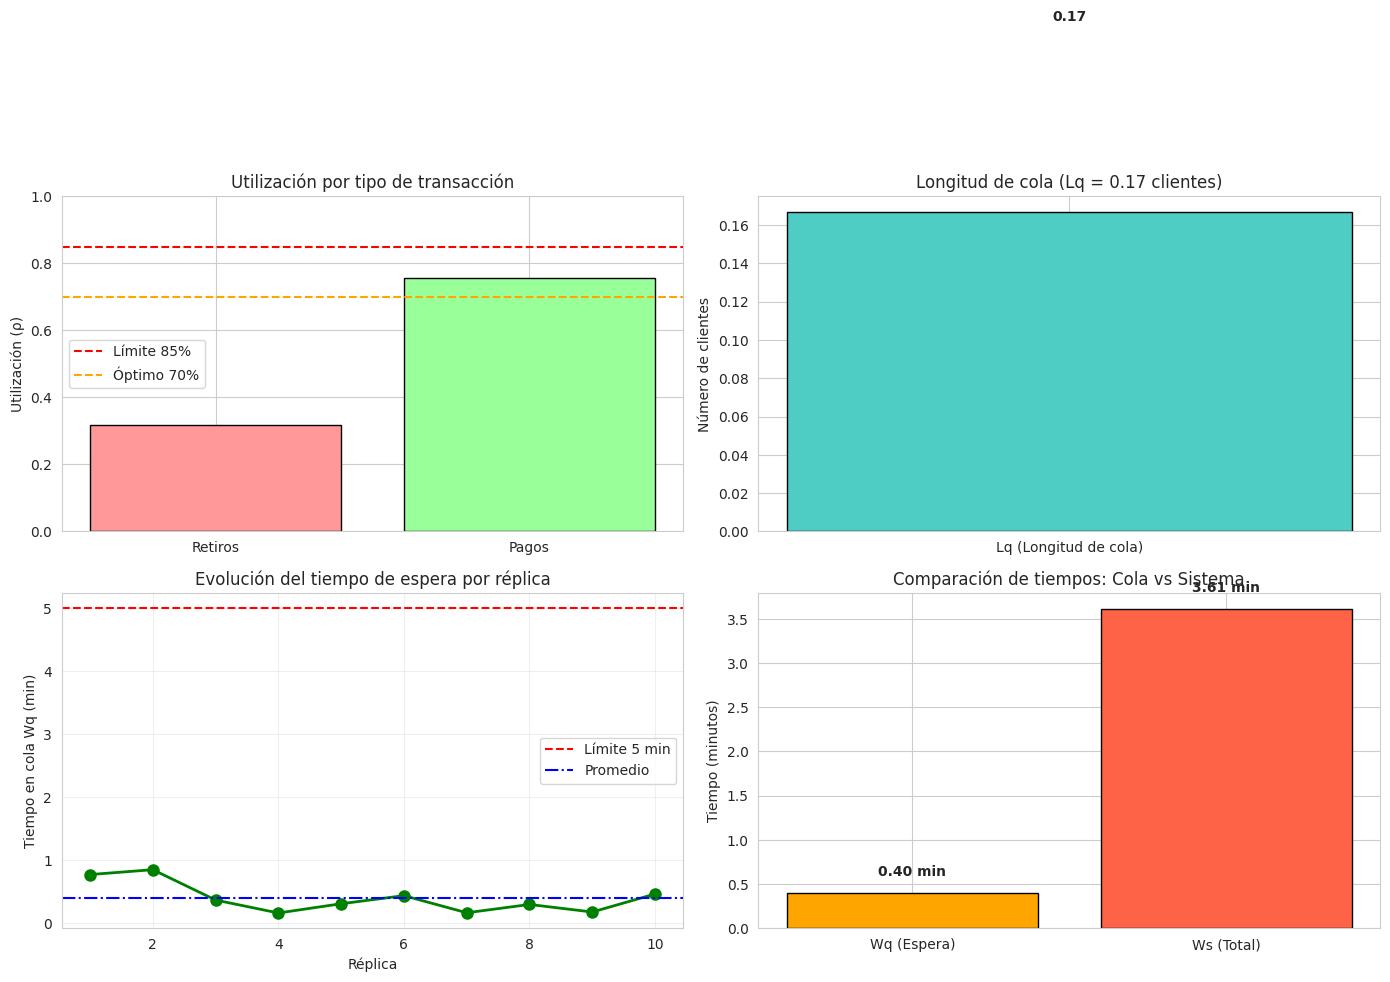


🎯 PUNTO 5: ANÁLISIS DE CONFIGURACIÓN ÓPTIMA

🔄 Ejecutando simulaciones...
--------------------------------------------------

📊 A: 3 Mixtas
   Réplica 1/10...
   Réplica 2/10...
   Réplica 3/10...
   Réplica 4/10...
   Réplica 5/10...
   Réplica 6/10...
   Réplica 7/10...
   Réplica 8/10...
   Réplica 9/10...
   Réplica 10/10...

📊 B: 1 Retiro + 2 Pagos
   Réplica 1/10...
   Réplica 2/10...
   Réplica 3/10...
   Réplica 4/10...
   Réplica 5/10...
   Réplica 6/10...
   Réplica 7/10...
   Réplica 8/10...
   Réplica 9/10...
   Réplica 10/10...

📊 C: 2 Retiros + 1 Pago
   Réplica 1/10...
   Réplica 2/10...
   Réplica 3/10...
   Réplica 4/10...
   Réplica 5/10...
   Réplica 6/10...
   Réplica 7/10...
   Réplica 8/10...
   Réplica 9/10...
   Réplica 10/10...

📊 RESULTADOS COMPARATIVOS

        Configuración  Espera Total (min)  Espera Retiros (min)  Espera Pagos (min)  % > 5 min
          A: 3 Mixtas                0.40                  0.39                0.41        1.5
B: 1 Retiro + 2 Pa

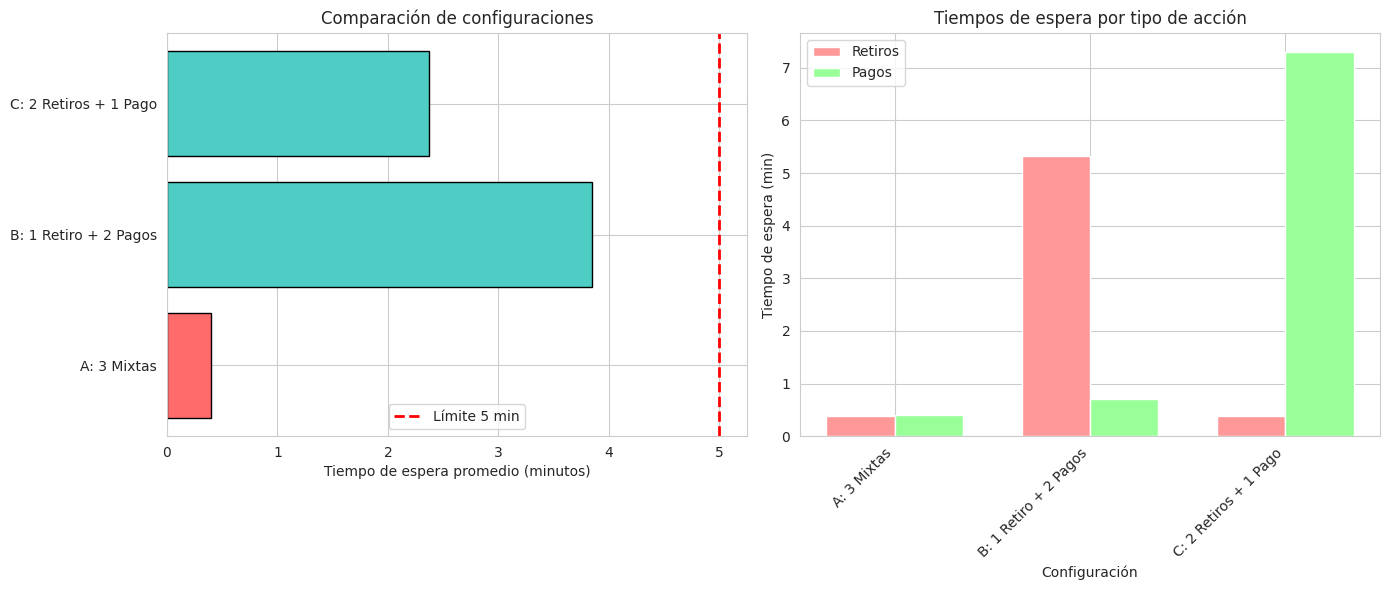


💾 Resultados guardados en 'resultados_simulacion_banco.xlsx'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ SIMULACIÓN COMPLETADA


In [ ]:
# ============================================
# SIMULACIÓN DE BANCO - CÓDIGO PARA COLAB
# ============================================

# Instalar dependencias necesarias
!pip install openpyxl

# Importar librerías
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import re
import math  # IMPORTANTE: para factorial

# ============================================
# CLASE DE SIMULACIÓN BASE (CAJEROS MIXTOS)
# ============================================

class BankSimulation:
    def __init__(self, num_cajeros=3, horas_operacion=8):
        self.num_cajeros = num_cajeros
        self.tiempo_simulacion = horas_operacion * 60

        self.prob_retiro = 0.7
        self.prob_pago = 0.3

        self.prob_usuario_retiro = [0.23, 0.40, 0.17, 0.20]
        self.prob_usuario_pago = [0.10, 0.20, 0.30, 0.40]

        self.servicio_retiro = [1, 2, 3, 4]
        self.servicio_pago = [3, 3, 5, 7]

        self.llegada_retiro = [1, 2, 3, 3]
        self.llegada_pago = [1, 2, 3, 4]

    def generar_tiempo_exponencial(self, media):
        return np.random.exponential(media)

    def generar_tipo_accion(self):
        return 'retiro' if np.random.random() < self.prob_retiro else 'pago'

    def generar_tipo_usuario(self, tipo_accion):
        if tipo_accion == 'retiro':
            return np.random.choice([0, 1, 2, 3], p=self.prob_usuario_retiro)
        else:
            return np.random.choice([0, 1, 2, 3], p=self.prob_usuario_pago)

    def simular_dia(self, semilla=None):
        if semilla is not None:
            np.random.seed(semilla)

        clientes_atendidos = []
        cajeros_ocupados = [0] * self.num_cajeros
        eventos = []
        tiempo_actual = 0

        tipo_accion = self.generar_tipo_accion()
        tipo_usuario = self.generar_tipo_usuario(tipo_accion)
        if tipo_accion == 'retiro':
            tiempo_llegada = self.generar_tiempo_exponencial(self.llegada_retiro[tipo_usuario])
        else:
            tiempo_llegada = self.generar_tiempo_exponencial(self.llegada_pago[tipo_usuario])

        eventos.append((tiempo_llegada, 'llegada', tipo_accion, tipo_usuario, None))
        cola = []

        while tiempo_actual < self.tiempo_simulacion:
            if not eventos:
                break

            eventos.sort(key=lambda x: x[0])
            evento = eventos.pop(0)
            tiempo_actual = evento[0]

            if tiempo_actual > self.tiempo_simulacion:
                break

            tipo_evento = evento[1]

            if tipo_evento == 'llegada':
                tipo_accion = evento[2]
                tipo_usuario = evento[3]

                cajero_disponible = None
                for i in range(self.num_cajeros):
                    if cajeros_ocupados[i] == 0:
                        cajero_disponible = i
                        break

                if cajero_disponible is not None:
                    cajeros_ocupados[cajero_disponible] = 1

                    if tipo_accion == 'retiro':
                        tiempo_servicio = self.generar_tiempo_exponencial(self.servicio_retiro[tipo_usuario])
                    else:
                        tiempo_servicio = self.generar_tiempo_exponencial(self.servicio_pago[tipo_usuario])

                    tiempo_fin = tiempo_actual + tiempo_servicio
                    eventos.append((tiempo_fin, 'fin_servicio', tipo_accion, tipo_usuario, cajero_disponible))

                    clientes_atendidos.append({
                        'tipo_accion': tipo_accion,
                        'tipo_usuario': tipo_usuario,
                        'tiempo_espera': 0,
                        'tiempo_servicio': tiempo_servicio,
                        'cajero': cajero_disponible
                    })
                else:
                    cola.append((tiempo_actual, tipo_accion, tipo_usuario))

                tipo_accion_nueva = self.generar_tipo_accion()
                tipo_usuario_nuevo = self.generar_tipo_usuario(tipo_accion_nueva)
                if tipo_accion_nueva == 'retiro':
                    tiempo_llegada = tiempo_actual + self.generar_tiempo_exponencial(
                        self.llegada_retiro[tipo_usuario_nuevo])
                else:
                    tiempo_llegada = tiempo_actual + self.generar_tiempo_exponencial(
                        self.llegada_pago[tipo_usuario_nuevo])

                eventos.append((tiempo_llegada, 'llegada', tipo_accion_nueva, tipo_usuario_nuevo, None))

            elif tipo_evento == 'fin_servicio':
                cajero = evento[4]
                cajeros_ocupados[cajero] = 0

                if cola:
                    cliente_cola = cola.pop(0)
                    tiempo_llegada_cola = cliente_cola[0]
                    tipo_accion_cola = cliente_cola[1]
                    tipo_usuario_cola = cliente_cola[2]
                    tiempo_espera = tiempo_actual - tiempo_llegada_cola

                    cajeros_ocupados[cajero] = 1

                    if tipo_accion_cola == 'retiro':
                        tiempo_servicio = self.generar_tiempo_exponencial(self.servicio_retiro[tipo_usuario_cola])
                    else:
                        tiempo_servicio = self.generar_tiempo_exponencial(self.servicio_pago[tipo_usuario_cola])

                    tiempo_fin = tiempo_actual + tiempo_servicio
                    eventos.append((tiempo_fin, 'fin_servicio', tipo_accion_cola, tipo_usuario_cola, cajero))

                    clientes_atendidos.append({
                        'tipo_accion': tipo_accion_cola,
                        'tipo_usuario': tipo_usuario_cola,
                        'tiempo_espera': tiempo_espera,
                        'tiempo_servicio': tiempo_servicio,
                        'cajero': cajero
                    })

        return pd.DataFrame(clientes_atendidos)

    def ejecutar_replicas(self, num_replicas=10):
        resultados = []
        for i in range(num_replicas):
            print(f"   Réplica {i+1}/{num_replicas}...")
            df = self.simular_dia(semilla=i)
            df['replica'] = i + 1
            resultados.append(df)
        return pd.concat(resultados, ignore_index=True)


# ============================================
# CLASE PARA SIMULACIÓN CON CAJEROS EXCLUSIVOS
# ============================================

class BankSimulationEspecializada:
    def __init__(self, num_cajeros_retiro=0, num_cajeros_pago=0, horas_operacion=8):
        self.num_cajeros_retiro = num_cajeros_retiro
        self.num_cajeros_pago = num_cajeros_pago
        self.num_cajeros_total = num_cajeros_retiro + num_cajeros_pago
        self.tiempo_simulacion = horas_operacion * 60

        if self.num_cajeros_total == 0:
            self.num_cajeros_total = 3
            self.es_mixto = True
        else:
            self.es_mixto = False

        self.prob_retiro = 0.7
        self.prob_pago = 0.3

        self.prob_usuario_retiro = [0.23, 0.40, 0.17, 0.20]
        self.prob_usuario_pago = [0.10, 0.20, 0.30, 0.40]

        self.servicio_retiro = [1, 2, 3, 4]
        self.servicio_pago = [3, 3, 5, 7]

        self.llegada_retiro = [1, 2, 3, 3]
        self.llegada_pago = [1, 2, 3, 4]

    def generar_tiempo_exponencial(self, media):
        return np.random.exponential(media)

    def generar_tipo_accion(self):
        return 'retiro' if np.random.random() < self.prob_retiro else 'pago'

    def generar_tipo_usuario(self, tipo_accion):
        if tipo_accion == 'retiro':
            return np.random.choice([0, 1, 2, 3], p=self.prob_usuario_retiro)
        else:
            return np.random.choice([0, 1, 2, 3], p=self.prob_usuario_pago)

    def simular_dia(self, semilla=None):
        if semilla is not None:
            np.random.seed(semilla)

        clientes_atendidos = []

        cajeros_estado = []
        if self.es_mixto:
            for i in range(self.num_cajeros_total):
                cajeros_estado.append({'ocupado': 0, 'tipo': None})
        else:
            for i in range(self.num_cajeros_retiro):
                cajeros_estado.append({'ocupado': 0, 'tipo': 'retiro'})
            for i in range(self.num_cajeros_pago):
                cajeros_estado.append({'ocupado': 0, 'tipo': 'pago'})

        eventos = []
        tiempo_actual = 0

        tipo_accion = self.generar_tipo_accion()
        tipo_usuario = self.generar_tipo_usuario(tipo_accion)
        if tipo_accion == 'retiro':
            tiempo_llegada = self.generar_tiempo_exponencial(self.llegada_retiro[tipo_usuario])
        else:
            tiempo_llegada = self.generar_tiempo_exponencial(self.llegada_pago[tipo_usuario])

        eventos.append((tiempo_llegada, 'llegada', tipo_accion, tipo_usuario, None))

        cola_retiros = []
        cola_pagos = []

        while tiempo_actual < self.tiempo_simulacion:
            if not eventos:
                break

            eventos.sort(key=lambda x: x[0])
            evento = eventos.pop(0)
            tiempo_actual = evento[0]

            if tiempo_actual > self.tiempo_simulacion:
                break

            tipo_evento = evento[1]

            if tipo_evento == 'llegada':
                tipo_accion = evento[2]
                tipo_usuario = evento[3]

                cajero_disponible = None
                for i, cajero in enumerate(cajeros_estado):
                    if cajero['ocupado'] == 0:
                        if cajero['tipo'] is None or cajero['tipo'] == tipo_accion:
                            cajero_disponible = i
                            break

                if cajero_disponible is not None:
                    cajeros_estado[cajero_disponible]['ocupado'] = 1

                    if tipo_accion == 'retiro':
                        tiempo_servicio = self.generar_tiempo_exponencial(self.servicio_retiro[tipo_usuario])
                    else:
                        tiempo_servicio = self.generar_tiempo_exponencial(self.servicio_pago[tipo_usuario])

                    tiempo_fin = tiempo_actual + tiempo_servicio
                    eventos.append((tiempo_fin, 'fin_servicio', tipo_accion, tipo_usuario, cajero_disponible))

                    clientes_atendidos.append({
                        'tipo_accion': tipo_accion,
                        'tipo_usuario': tipo_usuario,
                        'tiempo_espera': 0,
                        'tiempo_servicio': tiempo_servicio,
                        'cajero': cajero_disponible
                    })
                else:
                    if tipo_accion == 'retiro':
                        cola_retiros.append((tiempo_actual, tipo_accion, tipo_usuario))
                    else:
                        cola_pagos.append((tiempo_actual, tipo_accion, tipo_usuario))

                tipo_accion_nueva = self.generar_tipo_accion()
                tipo_usuario_nuevo = self.generar_tipo_usuario(tipo_accion_nueva)
                if tipo_accion_nueva == 'retiro':
                    tiempo_llegada = tiempo_actual + self.generar_tiempo_exponencial(
                        self.llegada_retiro[tipo_usuario_nuevo])
                else:
                    tiempo_llegada = tiempo_actual + self.generar_tiempo_exponencial(
                        self.llegada_pago[tipo_usuario_nuevo])

                eventos.append((tiempo_llegada, 'llegada', tipo_accion_nueva, tipo_usuario_nuevo, None))

            elif tipo_evento == 'fin_servicio':
                cajero_idx = evento[4]
                cajeros_estado[cajero_idx]['ocupado'] = 0

                tipo_cajero = cajeros_estado[cajero_idx]['tipo']

                if tipo_cajero == 'retiro' or tipo_cajero is None:
                    cola_a_atender = cola_retiros
                else:
                    cola_a_atender = cola_pagos

                if len(cola_a_atender) == 0 and cajeros_estado[cajero_idx]['tipo'] is None:
                    if len(cola_retiros) > 0:
                        cola_a_atender = cola_retiros
                    elif len(cola_pagos) > 0:
                        cola_a_atender = cola_pagos

                if cola_a_atender:
                    cliente_cola = cola_a_atender.pop(0)
                    tiempo_llegada_cola = cliente_cola[0]
                    tipo_accion_cola = cliente_cola[1]
                    tipo_usuario_cola = cliente_cola[2]
                    tiempo_espera = tiempo_actual - tiempo_llegada_cola

                    cajeros_estado[cajero_idx]['ocupado'] = 1

                    if tipo_accion_cola == 'retiro':
                        tiempo_servicio = self.generar_tiempo_exponencial(self.servicio_retiro[tipo_usuario_cola])
                    else:
                        tiempo_servicio = self.generar_tiempo_exponencial(self.servicio_pago[tipo_usuario_cola])

                    tiempo_fin = tiempo_actual + tiempo_servicio
                    eventos.append((tiempo_fin, 'fin_servicio', tipo_accion_cola, tipo_usuario_cola, cajero_idx))

                    clientes_atendidos.append({
                        'tipo_accion': tipo_accion_cola,
                        'tipo_usuario': tipo_usuario_cola,
                        'tiempo_espera': tiempo_espera,
                        'tiempo_servicio': tiempo_servicio,
                        'cajero': cajero_idx
                    })

        return pd.DataFrame(clientes_atendidos)

    def ejecutar_replicas(self, num_replicas=10):
        resultados = []
        for i in range(num_replicas):
            print(f"   Réplica {i+1}/{num_replicas}...")
            df = self.simular_dia(semilla=i)
            df['replica'] = i + 1
            resultados.append(df)
        return pd.concat(resultados, ignore_index=True)


# ============================================
# FUNCIONES DE ANÁLISIS
# ============================================

def analizar_resultados(resultados):
    print("\n" + "="*50)
    print("ANÁLISIS DE RESULTADOS")
    print("="*50)

    print(f"\n📊 ESTADÍSTICAS GENERALES:")
    print(f"   Total de clientes atendidos: {len(resultados)}")
    print(f"   Tiempo promedio de espera: {resultados['tiempo_espera'].mean():.2f} min")
    print(f"   Tiempo promedio de servicio: {resultados['tiempo_servicio'].mean():.2f} min")

    tiempos_por_cajero = resultados.groupby('cajero')['tiempo_servicio'].mean()
    print(f"\n🏦 TIEMPO PROMEDIO DE SERVICIO POR CAJERO:")
    for cajero, tiempo in tiempos_por_cajero.items():
        print(f"   Cajero {cajero}: {tiempo:.2f} min")

    print(f"\n   ⚡ Cajero más rápido: Cajero {tiempos_por_cajero.idxmin()} ({tiempos_por_cajero.min():.2f} min)")
    print(f"   🐢 Cajero más lento: Cajero {tiempos_por_cajero.idxmax()} ({tiempos_por_cajero.max():.2f} min)")

    tipos_usuario = {0: 'Rápido', 1: 'Normal', 2: 'Lento', 3: 'Muy lento'}

    print(f"\n👥 DISTRIBUCIÓN DE USUARIOS POR TIPO:")
    for accion in ['retiro', 'pago']:
        print(f"\n   {accion.upper()}S:")
        df_accion = resultados[resultados['tipo_accion'] == accion]
        for tipo in range(4):
            count = len(df_accion[df_accion['tipo_usuario'] == tipo])
            if count > 0:
                porcentaje = (count / len(df_accion)) * 100
                print(f"      {tipos_usuario[tipo]}: {count} clientes ({porcentaje:.1f}%)")

    print(f"\n⏱️ ESTADÍSTICAS DE TIEMPOS POR TIPO DE ACCIÓN:")
    for accion in ['retiro', 'pago']:
        df_accion = resultados[resultados['tipo_accion'] == accion]
        if len(df_accion) > 0:
            print(f"\n   {accion.upper()}S ({len(df_accion)} clientes):")
            print(f"      Tiempo espera promedio: {df_accion['tiempo_espera'].mean():.2f} min")
            print(f"      Tiempo servicio promedio: {df_accion['tiempo_servicio'].mean():.2f} min")


def tabla_usuarios_por_replica(resultados):
    print("\n" + "="*70)
    print("📋 TABLA: TOTAL DE USUARIOS POR RÉPLICA Y TIPO")
    print("="*70)

    tipos_usuario = {0: 'Rápido', 1: 'Normal', 2: 'Lento', 3: 'Muy lento'}
    replicas = sorted(resultados['replica'].unique())

    datos_tabla = []
    for replica in replicas:
        df_replica = resultados[resultados['replica'] == replica]
        fila = {'Réplica': replica, 'Total_General': len(df_replica)}

        for accion in ['retiro', 'pago']:
            df_accion = df_replica[df_replica['tipo_accion'] == accion]
            fila[f'Total_{accion}'] = len(df_accion)
            for tipo in range(4):
                count = len(df_accion[df_accion['tipo_usuario'] == tipo])
                fila[f'{accion}_{tipos_usuario[tipo]}'] = count

        datos_tabla.append(fila)

    df_tabla = pd.DataFrame(datos_tabla)
    print("\n" + df_tabla.to_string(index=False))

    total_por_replica = resultados.groupby('replica').size()
    replica_min = total_por_replica.idxmin()
    print(f"\n✅ Réplica con MENOS clientes: Réplica {replica_min} ({total_por_replica.min()} clientes)")

    return df_tabla


def analizar_necesidad_nuevo_cajero(resultados):
    print("\n" + "="*70)
    print("🔍 PUNTO 4: ANÁLISIS DE NECESIDAD DE NUEVO CAJERO")
    print("="*70)

    tiempo_espera_promedio = resultados['tiempo_espera'].mean()
    espera_excesiva = resultados[resultados['tiempo_espera'] > 5]
    porcentaje_excesiva = (len(espera_excesiva) / len(resultados)) * 100

    print(f"\n📊 TIEMPOS DE ESPERA:")
    print(f"   Tiempo de espera PROMEDIO: {tiempo_espera_promedio:.2f} minutos")
    print(f"   Clientes con espera > 5 min: {len(espera_excesiva)} ({porcentaje_excesiva:.1f}%)")

    if tiempo_espera_promedio < 3:
        decision_espera = "✅ NO necesita nuevo cajero"
        nivel = "EXCELENTE"
    elif tiempo_espera_promedio < 5:
        decision_espera = "⚠️ Marginal - Monitorear"
        nivel = "ACEPTABLE"
    elif tiempo_espera_promedio < 8:
        decision_espera = "⚠️ ❌ Probablemente necesita"
        nivel = "ALTO"
    else:
        decision_espera = "❌ URGENTE - Necesita nuevo cajero"
        nivel = "CRÍTICO"

    print(f"\n   📈 Nivel: {nivel}")
    print(f"   📌 Decisión por tiempo de espera: {decision_espera}")

    # Calcular utilización
    tiempo_total = 8 * 60
    num_replicas = resultados['replica'].nunique()
    total_clientes = len(resultados)
    llegadas_por_minuto = total_clientes / (tiempo_total * num_replicas)
    servicio_promedio = resultados['tiempo_servicio'].mean()
    tasa_servicio = 1 / servicio_promedio
    rho = llegadas_por_minuto / (3 * tasa_servicio)

    print(f"\n📊 UTILIZACIÓN DEL SISTEMA:")
    print(f"   Factor de utilización (ρ): {rho:.2%}")

    if rho < 0.70:
        decision_rho = "✅ Cajeros suficientes"
    elif rho < 0.85:
        decision_rho = "⚠️ Aceptable - Monitorear"
    else:
        decision_rho = "❌ Necesita más cajeros"

    print(f"   📌 Decisión por utilización: {decision_rho}")

    # Decisión final
    print("\n" + "="*50)
    if tiempo_espera_promedio > 5 or rho > 0.85:
        print("🎯 DECISIÓN FINAL: ❌ SÍ es necesario crear un nuevo cajero")
        print("   Justificación: Los tiempos de espera superan el estándar bancario de 5 minutos")
        print("   y/o la utilización del sistema es demasiado alta (>85%)")
    else:
        print("🎯 DECISIÓN FINAL: ✅ NO es necesario crear un nuevo cajero")
        print("   Justificación: Los tiempos de espera están dentro del estándar bancario")

    return tiempo_espera_promedio, rho


# ============================================
# CÁLCULO DE MÉTRICAS ADICIONALES (Lq, Wq, Utilización)
# ============================================

def calcular_metricas_cola(resultados, num_cajeros=3):
    """
    Calcula métricas adicionales de teoría de colas:
    - λ (tasa de llegada)
    - μ (tasa de servicio)
    - ρ (utilización)
    - Lq (longitud de cola promedio)
    - Wq (tiempo de espera en cola promedio)
    - Ls (clientes en sistema)
    - Ws (tiempo en sistema)
    """

    print("\n" + "="*70)
    print("📊 MÉTRICAS ADICIONALES DE TEORÍA DE COLAS (M/M/c)")
    print("="*70)

    # Parámetros de tiempo
    horas_operacion = 8
    tiempo_total_minutos = horas_operacion * 60  # 480 minutos
    num_replicas = resultados['replica'].nunique()

    # ==========================================
    # 1. CÁLCULO DE λ (TASA DE LLEGADA)
    # ==========================================
    total_clientes = len(resultados)
    tiempo_total_simulacion = tiempo_total_minutos * num_replicas

    lambda_total = total_clientes / tiempo_total_simulacion  # clientes por minuto
    lambda_por_hora = lambda_total * 60  # clientes por hora

    print("\n📈 TASA DE LLEGADA (λ):")
    print(f"   λ = {total_clientes} clientes / {tiempo_total_simulacion:.0f} minutos")
    print(f"   λ = {lambda_total:.4f} clientes/minuto")
    print(f"   λ = {lambda_por_hora:.2f} clientes/hora")

    # ==========================================
    # 2. CÁLCULO DE μ (TASA DE SERVICIO)
    # ==========================================
    tiempo_servicio_promedio = resultados['tiempo_servicio'].mean()
    mu = 1 / tiempo_servicio_promedio  # clientes por minuto por cajero
    mu_por_hora = mu * 60

    print("\n📈 TASA DE SERVICIO (μ):")
    print(f"   Tiempo servicio promedio: {tiempo_servicio_promedio:.2f} minutos")
    print(f"   μ = 1 / {tiempo_servicio_promedio:.2f} = {mu:.4f} clientes/minuto/cajero")
    print(f"   μ = {mu_por_hora:.2f} clientes/hora/cajero")

    # ==========================================
    # 3. CÁLCULO DE ρ (UTILIZACIÓN)
    # ==========================================
    rho = lambda_total / (num_cajeros * mu)

    print("\n📈 UTILIZACIÓN DEL SISTEMA (ρ):")
    print(f"   ρ = λ / (c × μ)")
    print(f"   ρ = {lambda_total:.4f} / ({num_cajeros} × {mu:.4f})")
    print(f"   ρ = {rho:.2%}")

    if rho < 0.70:
        nivel_rho = "BAJA (Cajeros subutilizados)"
        recomendacion = "Se pueden reducir cajeros o aumentar promociones"
    elif rho < 0.85:
        nivel_rho = "ÓPTIMA (Balance adecuado)"
        recomendacion = "La configuración actual es eficiente"
    else:
        nivel_rho = "ALTA (Sobrecarga)"
        recomendacion = "Se recomienda agregar más cajeros"

    print(f"   Nivel: {nivel_rho}")
    print(f"   Recomendación: {recomendacion}")

    # ==========================================
    # 4. CÁLCULO DE Wq (TIEMPO EN COLA)
    # ==========================================
    tiempo_espera_promedio = resultados['tiempo_espera'].mean()

    print("\n📈 TIEMPO EN COLA (Wq):")
    print(f"   Wq = {tiempo_espera_promedio:.2f} minutos")
    print(f"   Wq = {tiempo_espera_promedio * 60:.0f} segundos")

    if tiempo_espera_promedio < 3:
        nivel_wq = "EXCELENTE"
    elif tiempo_espera_promedio < 5:
        nivel_wq = "ACEPTABLE"
    elif tiempo_espera_promedio < 8:
        nivel_wq = "ALTO"
    else:
        nivel_wq = "CRÍTICO"

    print(f"   Nivel: {nivel_wq}")

    # ==========================================
    # 5. CÁLCULO DE Lq (LONGITUD DE COLA)
    # ==========================================
    # Usando la Ley de Little
    Lq_real = lambda_total * tiempo_espera_promedio

    print("\n📈 LONGITUD DE COLA (Lq):")
    print(f"   Lq (Ley de Little) = λ × Wq")
    print(f"   Lq = {lambda_total:.4f} × {tiempo_espera_promedio:.2f}")
    print(f"   Lq = {Lq_real:.2f} clientes en cola (promedio)")

    # ==========================================
    # 6. CÁLCULO DE Ls (CLIENTES EN SISTEMA)
    # ==========================================
    Ls = Lq_real + (lambda_total / mu)

    print("\n📈 CLIENTES EN SISTEMA (Ls):")
    print(f"   Ls = Lq + λ/μ")
    print(f"   Ls = {Lq_real:.2f} + {lambda_total:.4f}/{mu:.4f}")
    print(f"   Ls = {Ls:.2f} clientes (en cola + siendo atendidos)")

    # ==========================================
    # 7. CÁLCULO DE Ws (TIEMPO EN SISTEMA)
    # ==========================================
    Ws = tiempo_espera_promedio + tiempo_servicio_promedio

    print("\n📈 TIEMPO EN SISTEMA (Ws):")
    print(f"   Ws = Wq + 1/μ")
    print(f"   Ws = {tiempo_espera_promedio:.2f} + {tiempo_servicio_promedio:.2f}")
    print(f"   Ws = {Ws:.2f} minutos por cliente")

    # ==========================================
    # 8. DESGLOSE POR TIPO DE ACCIÓN
    # ==========================================
    print("\n" + "="*70)
    print("📊 DESGLOSE POR TIPO DE ACCIÓN")
    print("="*70)

    for accion in ['retiro', 'pago']:
        df_accion = resultados[resultados['tipo_accion'] == accion]
        if len(df_accion) > 0:
            print(f"\n📍 {accion.upper()}S:")

            clientes_accion = len(df_accion)
            lambda_accion = clientes_accion / tiempo_total_simulacion
            print(f"   λ_{accion} = {lambda_accion:.4f} clientes/min")

            servicio_accion = df_accion['tiempo_servicio'].mean()
            mu_accion = 1 / servicio_accion
            print(f"   μ_{accion} = {mu_accion:.4f} clientes/min")

            espera_accion = df_accion['tiempo_espera'].mean()
            print(f"   Wq_{accion} = {espera_accion:.2f} min")

            Lq_accion = lambda_accion * espera_accion
            print(f"   Lq_{accion} = {Lq_accion:.2f} clientes")

    # ==========================================
    # 9. RESUMEN EJECUTIVO
    # ==========================================
    print("\n" + "="*70)
    print("📋 RESUMEN DE MÉTRICAS DE TEORÍA DE COLAS")
    print("="*70)

    resumen_metricas = pd.DataFrame([
        {'Métrica': 'λ (Tasa de llegada)', 'Valor': f'{lambda_total:.4f} clientes/min', 'Interpretación': f'{lambda_por_hora:.1f} clientes/hora'},
        {'Métrica': 'μ (Tasa de servicio)', 'Valor': f'{mu:.4f} clientes/min/cajero', 'Interpretación': f'{mu_por_hora:.1f} clientes/hora/cajero'},
        {'Métrica': 'ρ (Utilización)', 'Valor': f'{rho:.2%}', 'Interpretación': nivel_rho},
        {'Métrica': 'Lq (Longitud de cola)', 'Valor': f'{Lq_real:.2f} clientes', 'Interpretación': f'Esperan en promedio {Lq_real:.1f} personas'},
        {'Métrica': 'Wq (Tiempo en cola)', 'Valor': f'{tiempo_espera_promedio:.2f} min', 'Interpretación': nivel_wq},
        {'Métrica': 'Ls (Clientes en sistema)', 'Valor': f'{Ls:.2f} clientes', 'Interpretación': f'{Ls:.1f} personas en el banco en promedio'},
        {'Métrica': 'Ws (Tiempo en sistema)', 'Valor': f'{Ws:.2f} min', 'Interpretación': f'{Ws/60:.2f} horas por cliente'},
    ])

    print("\n" + resumen_metricas.to_string(index=False))

    # ==========================================
    # 10. GRÁFICA DE MÉTRICAS
    # ==========================================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Gráfica 1: Utilización por tipo de acción
    utilizaciones = []
    for accion in ['retiro', 'pago']:
        df_accion = resultados[resultados['tipo_accion'] == accion]
        if len(df_accion) > 0:
            servicio_accion = df_accion['tiempo_servicio'].mean()
            mu_accion = 1 / servicio_accion
            llegadas_accion = len(df_accion) / tiempo_total_simulacion
            if accion == 'retiro':
                cajeros_asignados = num_cajeros * 0.7
            else:
                cajeros_asignados = num_cajeros * 0.3
            rho_accion = llegadas_accion / (max(cajeros_asignados, 0.5) * mu_accion)
            utilizaciones.append(rho_accion)
        else:
            utilizaciones.append(0)

    axes[0, 0].bar(['Retiros', 'Pagos'], utilizaciones, color=['#ff9999', '#99ff99'], edgecolor='black')
    axes[0, 0].axhline(y=0.85, color='red', linestyle='--', label='Límite 85%')
    axes[0, 0].axhline(y=0.70, color='orange', linestyle='--', label='Óptimo 70%')
    axes[0, 0].set_ylabel('Utilización (ρ)')
    axes[0, 0].set_title('Utilización por tipo de transacción')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 1)

    # Gráfica 2: Lq
    axes[0, 1].bar(['Lq (Longitud de cola)'], [Lq_real], color='#4ecdc4', edgecolor='black')
    axes[0, 1].set_ylabel('Número de clientes')
    axes[0, 1].set_title(f'Longitud de cola (Lq = {Lq_real:.2f} clientes)')
    axes[0, 1].text(0, Lq_real + 0.1, f'{Lq_real:.2f}', ha='center', fontweight='bold')

    # Gráfica 3: Evolución de Wq por réplica
    wq_por_replica = resultados.groupby('replica')['tiempo_espera'].mean()
    axes[1, 0].plot(wq_por_replica.index, wq_por_replica.values, marker='o', linewidth=2, markersize=8, color='green')
    axes[1, 0].axhline(y=5, color='red', linestyle='--', label='Límite 5 min')
    axes[1, 0].axhline(y=wq_por_replica.mean(), color='blue', linestyle='-.', label='Promedio')
    axes[1, 0].set_xlabel('Réplica')
    axes[1, 0].set_ylabel('Tiempo en cola Wq (min)')
    axes[1, 0].set_title('Evolución del tiempo de espera por réplica')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Gráfica 4: Relación Ws vs Wq
    tiempos = ['Wq (Espera)', 'Ws (Total)']
    valores_tiempos = [tiempo_espera_promedio, Ws]
    axes[1, 1].bar(tiempos, valores_tiempos, color=['#ffa500', '#ff6347'], edgecolor='black')
    axes[1, 1].set_ylabel('Tiempo (minutos)')
    axes[1, 1].set_title('Comparación de tiempos: Cola vs Sistema')
    for i, v in enumerate(valores_tiempos):
        axes[1, 1].text(i, v + 0.2, f'{v:.2f} min', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    return {
        'lambda': lambda_total,
        'mu': mu,
        'rho': rho,
        'Lq': Lq_real,
        'Wq': tiempo_espera_promedio,
        'Ls': Ls,
        'Ws': Ws,
        'tiempo_servicio_promedio': tiempo_servicio_promedio
    }


# ============================================
# ANÁLISIS DE CONFIGURACIÓN ÓPTIMA (PUNTO 5)
# ============================================

def analizar_configuraciones_optimas(num_replicas=10, horas_operacion=8):
    print("\n" + "="*70)
    print("🎯 PUNTO 5: ANÁLISIS DE CONFIGURACIÓN ÓPTIMA")
    print("="*70)

    configuraciones = {
        "A: 3 Mixtas": {'retiros': 0, 'pagos': 0, 'simulador': None},
        "B: 1 Retiro + 2 Pagos": {'retiros': 1, 'pagos': 2, 'simulador': None},
        "C: 2 Retiros + 1 Pago": {'retiros': 2, 'pagos': 1, 'simulador': None}
    }

    print("\n🔄 Ejecutando simulaciones...")
    print("-" * 50)

    resultados_por_config = {}

    for nombre, config in configuraciones.items():
        print(f"\n📊 {nombre}")
        if config['retiros'] == 0 and config['pagos'] == 0:
            sim = BankSimulation(num_cajeros=3, horas_operacion=horas_operacion)
        else:
            sim = BankSimulationEspecializada(
                num_cajeros_retiro=config['retiros'],
                num_cajeros_pago=config['pagos'],
                horas_operacion=horas_operacion
            )

        resultados = sim.ejecutar_replicas(num_replicas=num_replicas)
        resultados_por_config[nombre] = resultados

    # Comparativa
    print("\n" + "="*70)
    print("📊 RESULTADOS COMPARATIVOS")
    print("="*70)

    comparativa = []
    for nombre, df in resultados_por_config.items():
        tiempo_espera_total = df['tiempo_espera'].mean()
        tiempo_espera_retiros = df[df['tipo_accion'] == 'retiro']['tiempo_espera'].mean() if len(df[df['tipo_accion'] == 'retiro']) > 0 else 0
        tiempo_espera_pagos = df[df['tipo_accion'] == 'pago']['tiempo_espera'].mean() if len(df[df['tipo_accion'] == 'pago']) > 0 else 0

        pct_excede = (len(df[df['tiempo_espera'] > 5]) / len(df)) * 100

        comparativa.append({
            'Configuración': nombre,
            'Espera Total (min)': round(tiempo_espera_total, 2),
            'Espera Retiros (min)': round(tiempo_espera_retiros, 2),
            'Espera Pagos (min)': round(tiempo_espera_pagos, 2),
            '% > 5 min': round(pct_excede, 1)
        })

    df_comparativa = pd.DataFrame(comparativa)
    print("\n" + df_comparativa.to_string(index=False))

    # Mejor configuración
    mejor_idx = df_comparativa['Espera Total (min)'].idxmin()
    mejor_config = df_comparativa.loc[mejor_idx, 'Configuración']

    print("\n" + "="*70)
    print("🎯 CONFIGURACIÓN ÓPTIMA")
    print("="*70)
    print(f"\n🏆 MEJOR CONFIGURACIÓN: {mejor_config}")

    # Gráfica
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    configs = df_comparativa['Configuración'].tolist()
    esperas = df_comparativa['Espera Total (min)'].tolist()
    colores = ['#ff6b6b' if c == mejor_config else '#4ecdc4' for c in configs]

    axes[0].barh(configs, esperas, color=colores, edgecolor='black')
    axes[0].axvline(x=5, color='red', linestyle='--', linewidth=2, label='Límite 5 min')
    axes[0].set_xlabel('Tiempo de espera promedio (minutos)')
    axes[0].set_title('Comparación de configuraciones')
    axes[0].legend()

    x = np.arange(len(configs))
    width = 0.35
    retiros_espera = df_comparativa['Espera Retiros (min)'].tolist()
    pagos_espera = df_comparativa['Espera Pagos (min)'].tolist()

    axes[1].bar(x - width/2, retiros_espera, width, label='Retiros', color='#ff9999')
    axes[1].bar(x + width/2, pagos_espera, width, label='Pagos', color='#99ff99')
    axes[1].set_xlabel('Configuración')
    axes[1].set_ylabel('Tiempo de espera (min)')
    axes[1].set_title('Tiempos de espera por tipo de acción')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(configs, rotation=45, ha='right')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return df_comparativa, mejor_config, resultados_por_config


# ============================================
# FUNCIÓN PRINCIPAL
# ============================================

def main():
    print("🏦 SIMULACIÓN DE OPERACIONES BANCARIAS")
    print("="*50)

    NUM_CAJEROS = 3
    HORAS_OPERACION = 8
    NUM_REPLICAS = 10

    print(f"\nConfiguración:")
    print(f"  - Cajeros: {NUM_CAJEROS}")
    print(f"  - Horas de operación: {HORAS_OPERACION}")
    print(f"  - Réplicas: {NUM_REPLICAS}")

    # Simulación base
    print("\n🔄 Ejecutando simulación base...")
    sim = BankSimulation(num_cajeros=NUM_CAJEROS, horas_operacion=HORAS_OPERACION)
    resultados = sim.ejecutar_replicas(num_replicas=NUM_REPLICAS)

    # Análisis básicos
    analizar_resultados(resultados)
    tabla_usuarios_por_replica(resultados)
    analizar_necesidad_nuevo_cajero(resultados)

    # MÉTRICAS ADICIONALES (Lq, Wq, Utilización)
    metricas = calcular_metricas_cola(resultados, num_cajeros=NUM_CAJEROS)

    # Punto 5: Configuración óptima
    df_comparativa, mejor_config, resultados_configs = analizar_configuraciones_optimas(
        num_replicas=NUM_REPLICAS,
        horas_operacion=HORAS_OPERACION
    )

    # Guardar resultados
    archivo_excel = 'resultados_simulacion_banco.xlsx'
    with pd.ExcelWriter(archivo_excel, engine='openpyxl') as writer:
        resultados.to_excel(writer, sheet_name='Datos_Completos', index=False)
        df_comparativa.to_excel(writer, sheet_name='Comparativa_Configuraciones', index=False)

    print(f"\n💾 Resultados guardados en '{archivo_excel}'")
    files.download(archivo_excel)

    print("\n✅ SIMULACIÓN COMPLETADA")
    return resultados, metricas, df_comparativa, mejor_config


# ============================================
# EJECUTAR
# ============================================

if __name__ == "__main__":
    resultados, metricas, comparativa, mejor_config = main()